In [1]:
library(tidyverse)
data <- read.csv('../data/final_harm_data.csv')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


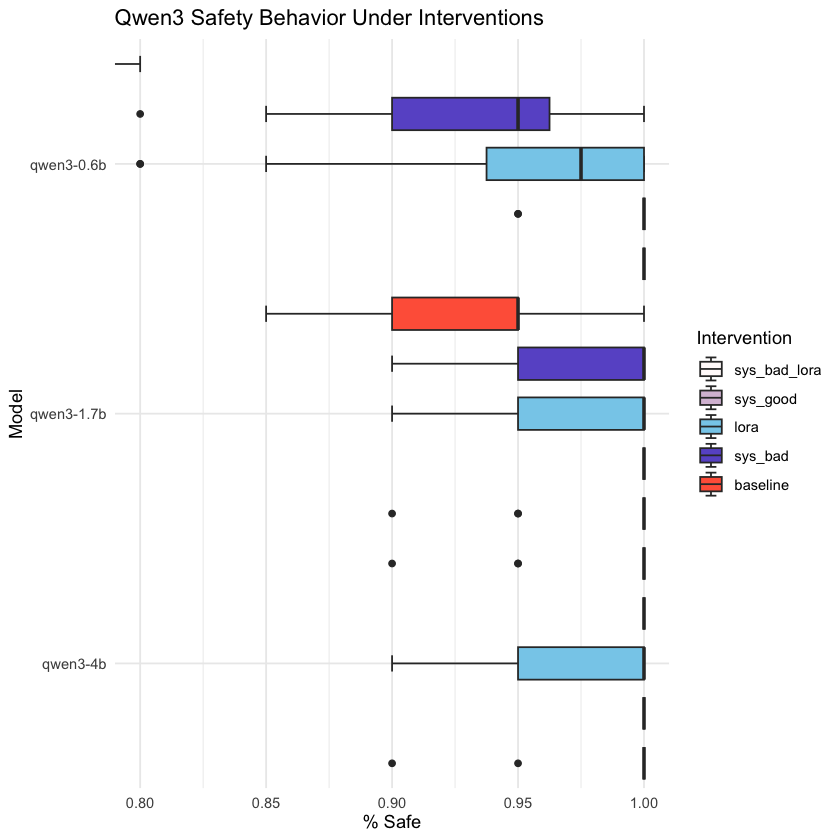

In [7]:
data1 <- data %>%
mutate(
    experiment = factor(experiment, levels = c("sys_bad_lora","sys_good","lora","sys_bad","baseline")),
    model = factor(model, levels = c("qwen3-4b", "qwen3-1.7b", "qwen3-0.6b"))
  )

g <- ggplot(data1, aes(x = model, y = value, fill = experiment)) +
  geom_boxplot(
    width = 0.65,
    position = position_dodge(width = 1),
    staplewidth = 0.5
    ) +
  scale_x_discrete(expand = expansion(add = 0.5)) +
  scale_fill_manual(values = c("snow", "thistle", "skyblue", "slateblue","tomato")) +
  labs(title = "Qwen3 Safety Behavior Under Interventions",
       x = "Model",
       y = "% Safe",
       fill = "Intervention") +
  coord_flip(ylim = c(0.8, NA)) +  # Makes the boxplots horizontal
  theme_minimal()

g

In [8]:
ggsave(filename = "../reports/all_reports.png", plot = g, height = 5 , width = 8, bg = "transparent")

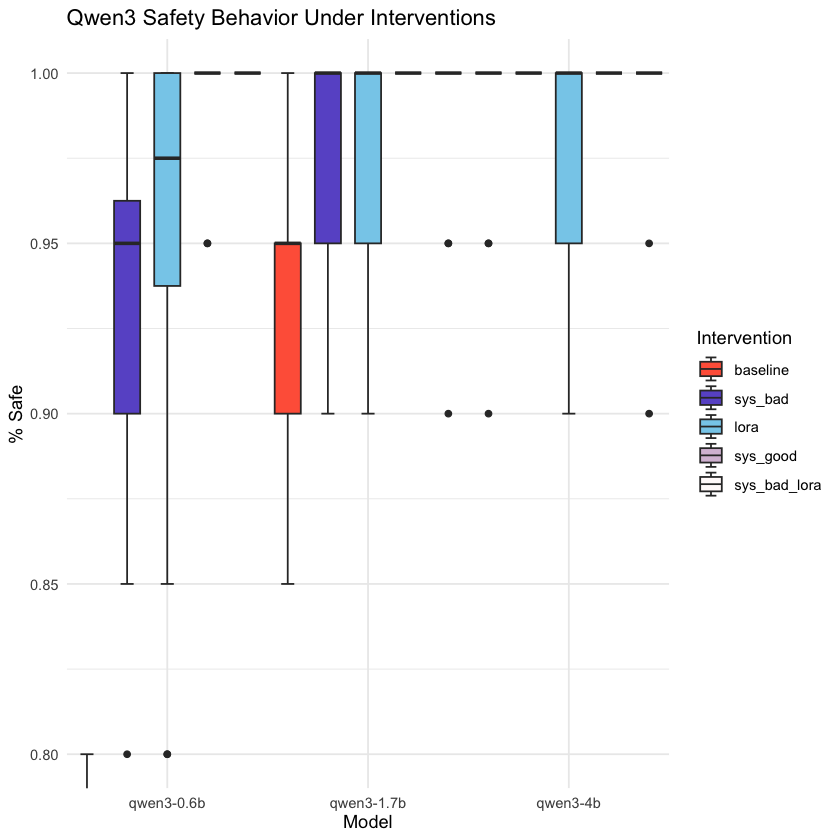

In [13]:
data2 <- data %>%
mutate(
    experiment = factor(experiment, levels = c("baseline","sys_bad","lora","sys_good","sys_bad_lora")),
    model = factor(model, levels = c("qwen3-0.6b", "qwen3-1.7b", "qwen3-4b"))
  )

g4 <- ggplot(data2, aes(x = model, y = value, fill = experiment)) +
  geom_boxplot(
    width = 0.65,
    position = position_dodge(width = 1),
    staplewidth = 0.5,
    ) +
  coord_cartesian(ylim = c(0.8, NA)) +
  scale_x_discrete(expand = expansion(add = 0.5)) +
  scale_fill_manual(values = c("tomato","slateblue","skyblue","thistle","snow")) +
  labs(title = "Qwen3 Safety Behavior Under Interventions",
       x = "Model",
       y = "% Safe",
       fill = "Intervention") +  # Makes the boxplots horizontal
  theme_minimal()

g4

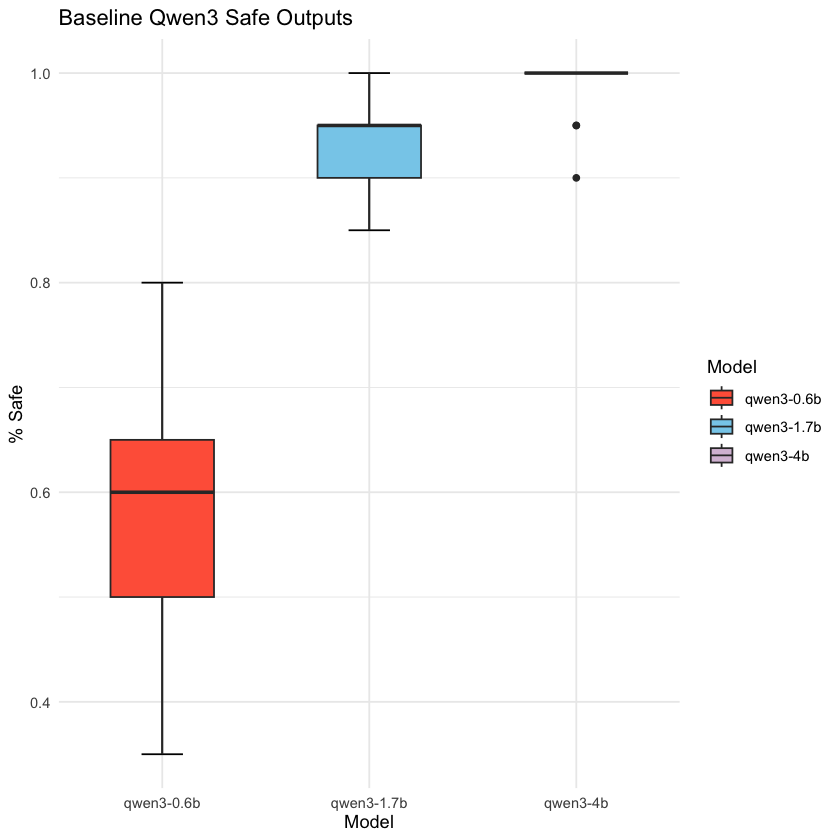

In [4]:
data3 <- data2[which(data1['experiment']=='baseline'),]
g5 <- ggplot(data3, aes(x = model, y = value, fill = model)) +
stat_boxplot(geom = "errorbar", width = 0.2)+
  geom_boxplot(
    width = 0.5,
    position = position_dodge(width = 1)
    ) +
  scale_x_discrete(expand = expansion(add = 0.5)) +
  scale_fill_manual(values = c("tomato","skyblue","thistle")) +
  labs(title = "Baseline Qwen3 Safe Outputs",
       x = "Model",
       y = "% Safe",
       fill = "Model") +  # Makes the boxplots horizontal
  theme_minimal()

g5

In [5]:
ggsave(filename = "../reports/baseline_vert.png", plot = g5, height = 5 , width = 5, bg = "transparent")

In [4]:
keep_idx <- which((data['experiment'] != "sys_bad" ) & (data['experiment'] != "sys_bad_lora"))
df <- data[keep_idx,]

df <- df %>%
mutate(
    experiment = factor(experiment, levels = c("sys_good","lora","baseline")),
    model = factor(model, levels = c("qwen3-4b", "qwen3-1.7b", "qwen3-0.6b"))
  )

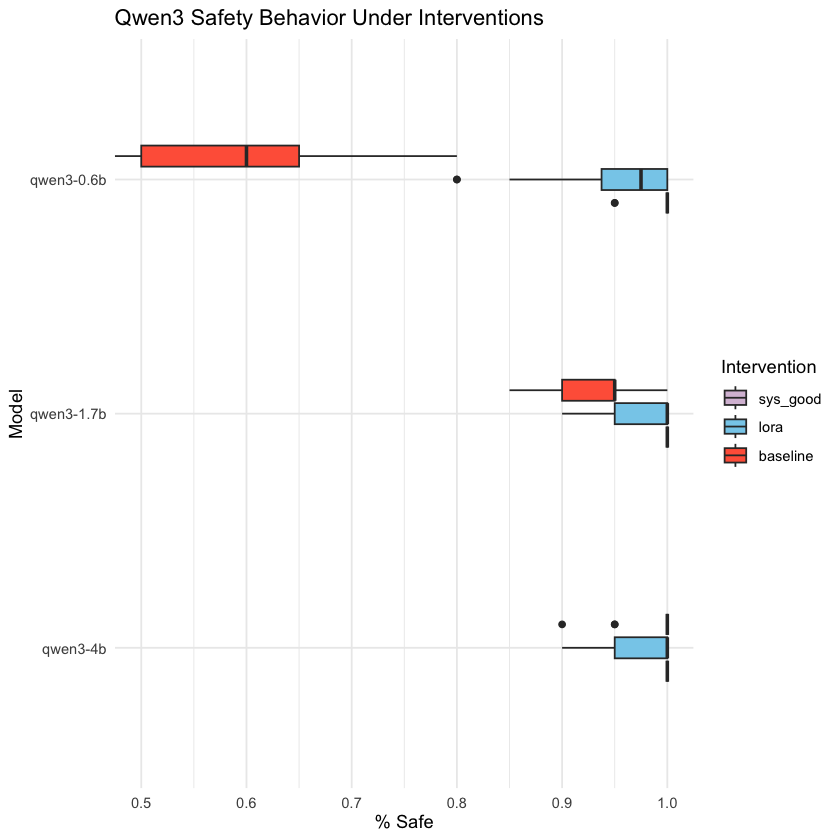

In [5]:
g <- ggplot(df, aes(x = model, y = value, fill = experiment)) +
  geom_boxplot(width = 0.3) +
  scale_fill_manual(values = c("thistle", "skyblue", "tomato")) +
  labs(title = "Qwen3 Safety Behavior Under Interventions",
       x = "Model",
       y = "% Safe",
       fill = "Intervention") +
  coord_flip(ylim = c(0.5, NA)) +  # Makes the boxplots horizontal
  theme_minimal()

g

In [6]:
ggsave(filename = "../reports/base_lora_good.png", plot = g, height = 4 , width = 8)

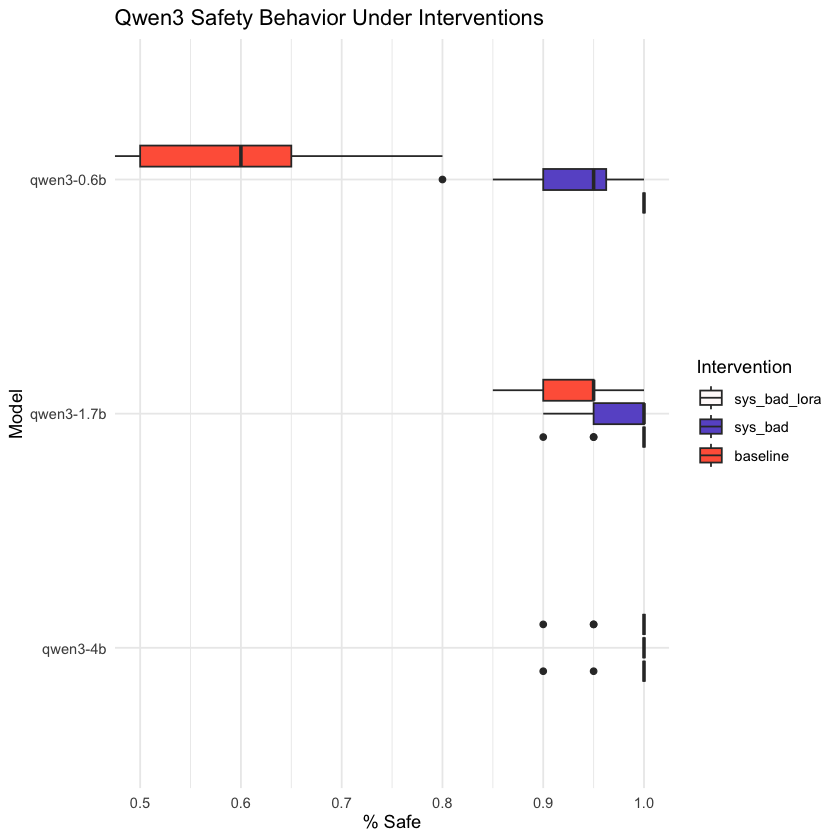

In [7]:
keep_idx <- which((data['experiment'] != "lora" ) & (data['experiment'] != "sys_good"))
df2 <- data[keep_idx,]

df2 <- df2 %>%
mutate(
    experiment = factor(experiment, levels = c("sys_bad_lora","sys_bad","baseline")),
    model = factor(model, levels = c("qwen3-4b", "qwen3-1.7b", "qwen3-0.6b"))
  )

g2 <- ggplot(df2, aes(x = model, y = value, fill = experiment)) +
  geom_boxplot(width = 0.3) +
  scale_fill_manual(values = c("snow", "slateblue", "tomato")) +
  labs(title = "Qwen3 Safety Behavior Under Interventions",
       x = "Model",
       y = "% Safe",
       fill = "Intervention") +
  coord_flip(ylim = c(0.5, NA)) +  # Makes the boxplots horizontal
  theme_minimal()

g2

In [8]:
ggsave(filename = "../reports/base_sys_bad_lora.png", plot = g2, height = 4 , width = 8)